# Cost-Aware and Explainable DSL for Tensor Optimization

This notebook implements a research prototype of an embedded Python DSL for tensor optimization strategy selection.

The system:
- represents tensor computations using TensorProgram
- generates candidate optimization strategies
- predicts strategies using a simple heuristic cost model
- validates decisions using runtime measurements
- provides explainable reasoning for strategy selection
- compares adaptive optimization against always-optimize and never-optimize approaches

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from dataclasses import dataclass

np.random.seed(42)

## DSL Program Representation

In [2]:
@dataclass
class TensorProgram:
    """
    A small DSL-level representation of a tensor computation.

    This is the user-facing DSL object.
    The user describes WHAT computation to run, not HOW to optimize it.
    """
    operation: str
    shape: tuple

    def __repr__(self):
        return f"TensorProgram(operation='{self.operation}', shape={self.shape})"

## Timing and Correctness Helper Functions

In [3]:
def time_function(func, repeat=5):
    """
    Runs a function several times and returns the best runtime.
    Using the best time helps reduce noise from Colab or system background activity.
    """
    best_time = float("inf")
    best_result = None

    for _ in range(repeat):
        start = time.perf_counter()
        result = func()
        end = time.perf_counter()

        elapsed = end - start

        if elapsed < best_time:
            best_time = elapsed
            best_result = result

    return best_time, best_result


def outputs_match(reference, candidate, tolerance=1e-6):
    """
    Checks whether two tensor outputs are numerically close.
    """
    return np.allclose(reference, candidate, atol=tolerance, rtol=tolerance)

## Cost-Aware DSL Implementation

In [4]:
class CostAwareTensorDSL:
    """
    Cost-aware and explainable embedded DSL for tensor optimization.

    Supported operations:
    1. elementwise_chain
    2. matmul

    Supported strategies:
    - baseline
    - fused
    - tiled

    Main idea:
    The DSL first predicts a strategy using a simple cost-aware heuristic.
    Then it validates the decision using runtime measurement.
    """

    def __init__(self):
        self.history = []

    # -------------------------
    # Elementwise operation
    # -------------------------

    def elementwise_baseline(self, x):
        a = np.cos(x)
        b = np.sin(a)
        c = np.exp(x)
        return b + c

    def elementwise_fused(self, x):
        return np.sin(np.cos(x)) + np.exp(x)

    # -------------------------
    # Matrix multiplication
    # -------------------------

    def matmul_baseline(self, A, B):
        return A @ B

    def matmul_tiled(self, A, B, tile_size=64):
        n = A.shape[0]
        C = np.zeros((n, n))

        for i in range(0, n, tile_size):
            for j in range(0, n, tile_size):
                for k in range(0, n, tile_size):
                    C[i:i + tile_size, j:j + tile_size] += (
                        A[i:i + tile_size, k:k + tile_size]
                        @ B[k:k + tile_size, j:j + tile_size]
                    )

        return C

    # -------------------------
    # Cost-aware heuristic
    # -------------------------

    def predict_strategy(self, operation, shape):
        """
        Simple cost-aware heuristic.

        This is intentionally simple because this is a course project prototype,
        not a full compiler cost model.
        """

        total_elements = np.prod(shape)

        if operation == "elementwise_chain":
            if total_elements < 128 * 128:
                return (
                    "baseline",
                    "Small elementwise workload: baseline may avoid optimization overhead."
                )
            else:
                return (
                    "fused",
                    "Medium or large elementwise chain: fusion may reduce intermediate arrays."
                )

        elif operation == "matmul":
            n = shape[0]

            if n < 256:
                return (
                    "baseline",
                    "Small matrix multiplication: NumPy baseline is likely efficient enough."
                )
            else:
                return (
                    "tiled",
                    "Larger matrix multiplication: tiled execution may improve locality."
                )

        else:
            raise ValueError(f"Unsupported operation: {operation}")

    # -------------------------
    # Candidate strategy generation
    # -------------------------

    def get_candidate_strategies(self, operation):
        if operation == "elementwise_chain":
            return ["baseline", "fused"]

        if operation == "matmul":
            return ["baseline", "tiled"]

        raise ValueError(f"Unsupported operation: {operation}")

    # -------------------------
    # Strategy execution
    # -------------------------

    def execute_strategy(self, operation, inputs, strategy):
        if operation == "elementwise_chain":
            x = inputs["x"]

            if strategy == "baseline":
                return self.elementwise_baseline(x)

            if strategy == "fused":
                return self.elementwise_fused(x)

        elif operation == "matmul":
            A = inputs["A"]
            B = inputs["B"]

            if strategy == "baseline":
                return self.matmul_baseline(A, B)

            if strategy == "tiled":
                return self.matmul_tiled(A, B)

        raise ValueError(f"Unsupported strategy {strategy} for operation {operation}")

    # -------------------------
    # Main DSL execution
    # -------------------------

    def run(self, program, repeat=5, verbose=True):
        """
        Runs a TensorProgram using:
        1. DSL interpretation
        2. cost-aware prediction
        3. runtime validation
        4. correctness checking
        5. explanation logging
        """

        operation = program.operation
        shape = program.shape

        # Create inputs from DSL program
        if operation == "elementwise_chain":
            inputs = {
                "x": np.random.rand(*shape)
            }

        elif operation == "matmul":
            inputs = {
                "A": np.random.rand(*shape),
                "B": np.random.rand(*shape)
            }

        else:
            raise ValueError(f"Unsupported DSL operation: {operation}")

        predicted_strategy, prediction_reason = self.predict_strategy(operation, shape)
        candidate_strategies = self.get_candidate_strategies(operation)

        timings = {}
        outputs = {}

        # Runtime validation
        for strategy in candidate_strategies:
            elapsed, result = time_function(
                lambda s=strategy: self.execute_strategy(operation, inputs, s),
                repeat=repeat
            )

            timings[strategy] = elapsed
            outputs[strategy] = result

        selected_strategy = min(timings, key=timings.get)

        baseline_output = outputs["baseline"]
        correctness = {
            strategy: outputs_match(baseline_output, outputs[strategy])
            for strategy in candidate_strategies
        }

        all_correct = all(correctness.values())

        baseline_time = timings["baseline"]
        selected_time = timings[selected_strategy]
        speedup_vs_baseline = baseline_time / selected_time

        prediction_matched_runtime = predicted_strategy == selected_strategy

        record = {
            "program": repr(program),
            "operation": operation,
            "shape": shape,
            "candidate_strategies": candidate_strategies,
            "predicted_strategy": predicted_strategy,
            "prediction_reason": prediction_reason,
            "selected_strategy": selected_strategy,
            "timings": timings,
            "correctness": correctness,
            "all_correct": all_correct,
            "baseline_time": baseline_time,
            "selected_time": selected_time,
            "speedup_vs_baseline": speedup_vs_baseline,
            "prediction_matched_runtime": prediction_matched_runtime
        }

        self.history.append(record)

        if verbose:
            print("Running DSL program:", program)
            print("Operation:", operation)
            print("Input shape:", shape)
            print("Predicted strategy:", predicted_strategy)
            print("Prediction reason:", prediction_reason)
            print("Candidate timings:", timings)
            print("Selected strategy after runtime validation:", selected_strategy)
            print("Correctness check passed:", all_correct)
            print("Speedup vs baseline:", speedup_vs_baseline)
            print("-" * 70)

        return record

## Tensor DSL Programs

In [5]:
programs = [
    TensorProgram("elementwise_chain", shape=(64, 64)),
    TensorProgram("elementwise_chain", shape=(128, 128)),
    TensorProgram("elementwise_chain", shape=(256, 256)),
    TensorProgram("elementwise_chain", shape=(512, 512)),
    TensorProgram("elementwise_chain", shape=(1024, 1024)),

    TensorProgram("matmul", shape=(64, 64)),
    TensorProgram("matmul", shape=(128, 128)),
    TensorProgram("matmul", shape=(256, 256)),
    TensorProgram("matmul", shape=(512, 512)),
]

## Running DSL Experiments

In [6]:
dsl = CostAwareTensorDSL()

for program in programs:
    dsl.run(program, repeat=5, verbose=True)

Running DSL program: TensorProgram(operation='elementwise_chain', shape=(64, 64))
Operation: elementwise_chain
Input shape: (64, 64)
Predicted strategy: baseline
Prediction reason: Small elementwise workload: baseline may avoid optimization overhead.
Candidate timings: {'baseline': 0.00025284399998781737, 'fused': 0.0002524380000181736}
Selected strategy after runtime validation: fused
Correctness check passed: True
Speedup vs baseline: 1.0016083155848743
----------------------------------------------------------------------
Running DSL program: TensorProgram(operation='elementwise_chain', shape=(128, 128))
Operation: elementwise_chain
Input shape: (128, 128)
Predicted strategy: fused
Prediction reason: Medium or large elementwise chain: fusion may reduce intermediate arrays.
Candidate timings: {'baseline': 0.0005977789999747074, 'fused': 0.0005680279999751292}
Selected strategy after runtime validation: fused
Correctness check passed: True
Speedup vs baseline: 1.0523759392158147
-----

## Detailed Strategy Evaluation Results

In [7]:
detailed_rows = []

for item in dsl.history:
    for strategy, runtime in item["timings"].items():
        detailed_rows.append({
            "Program": item["program"],
            "Operation": item["operation"],
            "Input Shape": str(item["shape"]),
            "Strategy": strategy,
            "Runtime (s)": runtime,
            "Predicted Strategy": item["predicted_strategy"],
            "Selected Strategy": item["selected_strategy"],
            "Strategy Correct?": item["correctness"][strategy],
            "All Outputs Correct?": item["all_correct"]
        })

detailed_df = pd.DataFrame(detailed_rows)
detailed_df

,Program,Operation,Input Shape,Strategy,Runtime (s),Predicted Strategy,Selected Strategy,Strategy Correct?,All Outputs Correct?
0,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(64, 64)",baseline,0.000253,baseline,fused,True,True
1,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(64, 64)",fused,0.000252,baseline,fused,True,True
2,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(128, 128)",baseline,0.000598,fused,fused,True,True
3,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(128, 128)",fused,0.000568,fused,fused,True,True
4,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(256, 256)",baseline,0.002419,fused,baseline,True,True
5,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(256, 256)",fused,0.002454,fused,baseline,True,True
6,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(512, 512)",baseline,0.010033,fused,fused,True,True
7,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(512, 512)",fused,0.009490,fused,fused,True,True
8,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(1024, 1024)",baseline,0.045351,fused,fused,True,True
9,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(1024, 1024)",fused,0.041180,fused,fused,True,True


## Summary of Cost-Aware Strategy Selection

In [8]:
summary_rows = []

for item in dsl.history:
    summary_rows.append({
        "Program": item["program"],
        "Operation": item["operation"],
        "Input Shape": str(item["shape"]),
        "Predicted Strategy": item["predicted_strategy"],
        "Selected Strategy": item["selected_strategy"],
        "Prediction Matched Runtime?": item["prediction_matched_runtime"],
        "Baseline Time (s)": item["baseline_time"],
        "Selected Time (s)": item["selected_time"],
        "Speedup vs Baseline": item["speedup_vs_baseline"],
        "Correct Output?": item["all_correct"],
        "Explanation": item["prediction_reason"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Program,Operation,Input Shape,Predicted Strategy,Selected Strategy,Prediction Matched Runtime?,Baseline Time (s),Selected Time (s),Speedup vs Baseline,Correct Output?,Explanation
0,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(64, 64)",baseline,fused,False,0.000253,0.000252,1.001608,True,Small elementwise workload: baseline may avoid...
1,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(128, 128)",fused,fused,True,0.000598,0.000568,1.052376,True,Medium or large elementwise chain: fusion may ...
2,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(256, 256)",fused,baseline,False,0.002419,0.002419,1.000000,True,Medium or large elementwise chain: fusion may ...
3,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(512, 512)",fused,fused,True,0.010033,0.009490,1.057169,True,Medium or large elementwise chain: fusion may ...
4,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(1024, 1024)",fused,fused,True,0.045351,0.041180,1.101289,True,Medium or large elementwise chain: fusion may ...
5,"TensorProgram(operation='matmul', shape=(64, 64))",matmul,"(64, 64)",baseline,baseline,True,0.000026,0.000026,1.000000,True,Small matrix multiplication: NumPy baseline is...
6,"TensorProgram(operation='matmul', shape=(128, ...",matmul,"(128, 128)",baseline,baseline,True,0.000160,0.000160,1.000000,True,Small matrix multiplication: NumPy baseline is...
7,"TensorProgram(operation='matmul', shape=(256, ...",matmul,"(256, 256)",tiled,baseline,False,0.001157,0.001157,1.000000,True,Larger matrix multiplication: tiled execution ...
8,"TensorProgram(operation='matmul', shape=(512, ...",matmul,"(512, 512)",tiled,baseline,False,0.009360,0.009360,1.000000,True,Larger matrix multiplication: tiled execution ...


## Optimization Benefit Analysis

In [9]:
benefit_rows = []

for item in dsl.history:
    baseline_time = item["baseline_time"]

    optimized_strategies = [
        strategy
        for strategy in item["candidate_strategies"]
        if strategy != "baseline"
    ]

    best_optimized_strategy = min(
        optimized_strategies,
        key=lambda strategy: item["timings"][strategy]
    )

    best_optimized_time = item["timings"][best_optimized_strategy]

    optimization_beneficial = best_optimized_time < baseline_time
    system_applied_optimization = item["selected_strategy"] != "baseline"
    correct_optimization_decision = optimization_beneficial == system_applied_optimization

    benefit_rows.append({
        "Program": item["program"],
        "Operation": item["operation"],
        "Input Shape": str(item["shape"]),
        "Baseline Time (s)": baseline_time,
        "Best Optimized Strategy": best_optimized_strategy,
        "Best Optimized Time (s)": best_optimized_time,
        "Optimization Beneficial?": optimization_beneficial,
        "System Selected": item["selected_strategy"],
        "System Applied Optimization?": system_applied_optimization,
        "Correct Optimization Decision?": correct_optimization_decision,
        "Correct Output?": item["all_correct"]
    })

benefit_df = pd.DataFrame(benefit_rows)
benefit_df

,Program,Operation,Input Shape,Baseline Time (s),Best Optimized Strategy,Best Optimized Time (s),Optimization Beneficial?,System Selected,System Applied Optimization?,Correct Optimization Decision?,Correct Output?
0,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(64, 64)",0.000253,fused,0.000252,True,fused,True,True,True
1,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(128, 128)",0.000598,fused,0.000568,True,fused,True,True,True
2,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(256, 256)",0.002419,fused,0.002454,False,baseline,False,True,True
3,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(512, 512)",0.010033,fused,0.009490,True,fused,True,True,True
4,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(1024, 1024)",0.045351,fused,0.041180,True,fused,True,True,True
5,"TensorProgram(operation='matmul', shape=(64, 64))",matmul,"(64, 64)",0.000026,tiled,0.000032,False,baseline,False,True,True
6,"TensorProgram(operation='matmul', shape=(128, ...",matmul,"(128, 128)",0.000160,tiled,0.000453,False,baseline,False,True,True
7,"TensorProgram(operation='matmul', shape=(256, ...",matmul,"(256, 256)",0.001157,tiled,0.003971,False,baseline,False,True,True
8,"TensorProgram(operation='matmul', shape=(512, ...",matmul,"(512, 512)",0.009360,tiled,0.024148,False,baseline,False,True,True


## Comparison of Optimization Approaches

In [10]:
comparison_rows = []

for item in dsl.history:
    baseline_time = item["baseline_time"]

    optimized_strategies = [
        strategy
        for strategy in item["candidate_strategies"]
        if strategy != "baseline"
    ]

    always_optimize_strategy = optimized_strategies[0]
    always_optimize_time = item["timings"][always_optimize_strategy]

    selected_time = item["selected_time"]

    comparison_rows.append({
        "Program": item["program"],
        "Operation": item["operation"],
        "Input Shape": str(item["shape"]),
        "Never Optimize Time (Baseline)": baseline_time,
        "Always Optimize Strategy": always_optimize_strategy,
        "Always Optimize Time": always_optimize_time,
        "DSL Selected Strategy": item["selected_strategy"],
        "DSL Selected Time": selected_time,
        "DSL Speedup vs Never Optimize": baseline_time / selected_time,
        "DSL Speedup vs Always Optimize": always_optimize_time / selected_time,
        "Correct Output?": item["all_correct"]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Program,Operation,Input Shape,Never Optimize Time (Baseline),Always Optimize Strategy,Always Optimize Time,DSL Selected Strategy,DSL Selected Time,DSL Speedup vs Never Optimize,DSL Speedup vs Always Optimize,Correct Output?
0,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(64, 64)",0.000253,fused,0.000252,fused,0.000252,1.001608,1.000000,True
1,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(128, 128)",0.000598,fused,0.000568,fused,0.000568,1.052376,1.000000,True
2,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(256, 256)",0.002419,fused,0.002454,baseline,0.002419,1.000000,1.014536,True
3,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(512, 512)",0.010033,fused,0.009490,fused,0.009490,1.057169,1.000000,True
4,"TensorProgram(operation='elementwise_chain', s...",elementwise_chain,"(1024, 1024)",0.045351,fused,0.041180,fused,0.041180,1.101289,1.000000,True
5,"TensorProgram(operation='matmul', shape=(64, 64))",matmul,"(64, 64)",0.000026,tiled,0.000032,baseline,0.000026,1.000000,1.254610,True
6,"TensorProgram(operation='matmul', shape=(128, ...",matmul,"(128, 128)",0.000160,tiled,0.000453,baseline,0.000160,1.000000,2.832815,True
7,"TensorProgram(operation='matmul', shape=(256, ...",matmul,"(256, 256)",0.001157,tiled,0.003971,baseline,0.001157,1.000000,3.431958,True
8,"TensorProgram(operation='matmul', shape=(512, ...",matmul,"(512, 512)",0.009360,tiled,0.024148,baseline,0.009360,1.000000,2.579825,True


## Final Evaluation Summary

In [11]:
total_cases = len(summary_df)

correct_outputs = summary_df["Correct Output?"].sum()
prediction_matches = summary_df["Prediction Matched Runtime?"].sum()
correct_optimization_decisions = benefit_df["Correct Optimization Decision?"].sum()

average_speedup_vs_baseline = summary_df["Speedup vs Baseline"].mean()
average_speedup_vs_always_optimize = comparison_df["DSL Speedup vs Always Optimize"].mean()

print("Final Evaluation Summary")
print("-" * 40)
print("Total test cases:", total_cases)
print("Correct output cases:", correct_outputs)
print("Prediction matched runtime-selected strategy:", prediction_matches)
print("Correct optimization decisions:", correct_optimization_decisions)
print("Average speedup vs baseline:", average_speedup_vs_baseline)
print("Average speedup vs always optimize:", average_speedup_vs_always_optimize)

Final Evaluation Summary
----------------------------------------
Total test cases: 9
Correct output cases: 9
Prediction matched runtime-selected strategy: 5
Correct optimization decisions: 9
Average speedup vs baseline: 1.0236046668625012
Average speedup vs always optimize: 1.6793048662366654


## Baseline vs DSL Runtime Plot

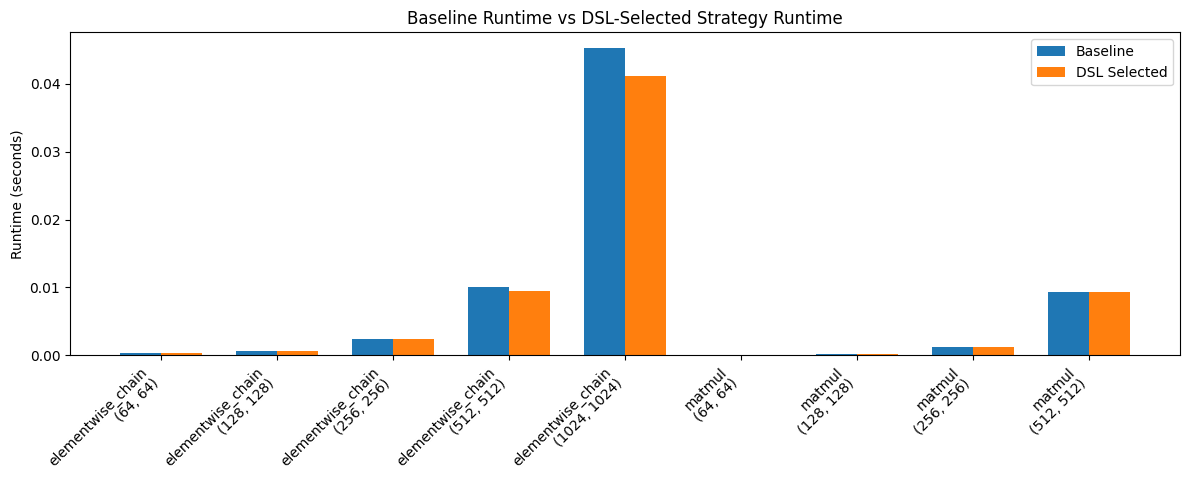

In [12]:
plot_df = summary_df.copy()

labels = plot_df["Operation"] + "\n" + plot_df["Input Shape"].astype(str)
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(
    x - width / 2,
    plot_df["Baseline Time (s)"],
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    plot_df["Selected Time (s)"],
    width,
    label="DSL Selected"
)

plt.ylabel("Runtime (seconds)")
plt.title("Baseline Runtime vs DSL-Selected Strategy Runtime")
plt.xticks(x, labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("baseline_vs_dsl_selected.png", dpi=200)
plt.show()

## Speedup Compared to Baseline

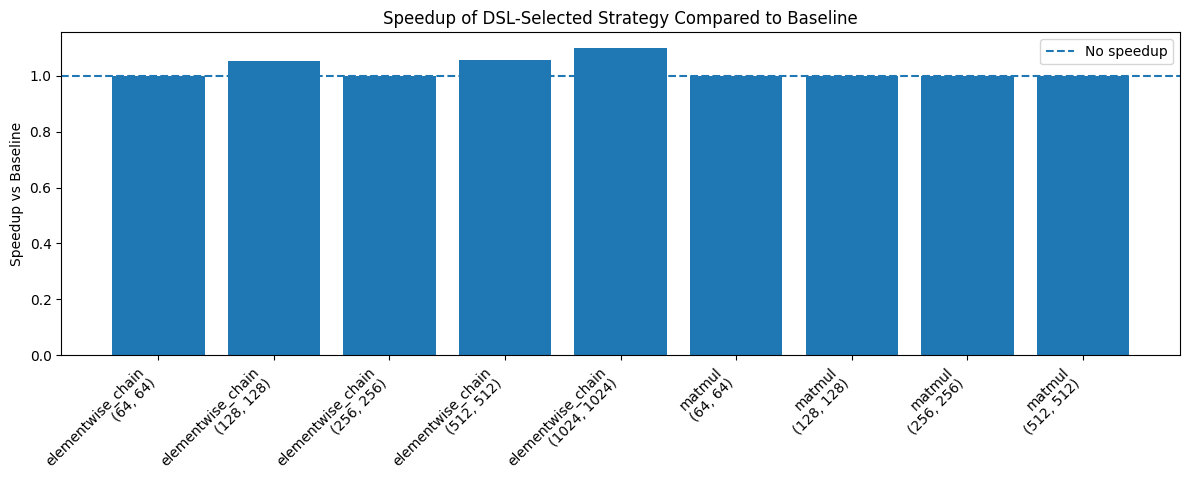

In [13]:
plot_df = summary_df.copy()

labels = plot_df["Operation"] + "\n" + plot_df["Input Shape"].astype(str)

plt.figure(figsize=(12, 5))

plt.bar(
    labels,
    plot_df["Speedup vs Baseline"]
)

plt.axhline(y=1.0, linestyle="--", label="No speedup")

plt.ylabel("Speedup vs Baseline")
plt.title("Speedup of DSL-Selected Strategy Compared to Baseline")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("speedup_vs_baseline.png", dpi=200)
plt.show()

## Comparison Plot: Never Optimize vs Always Optimize vs Cost-Aware DSL

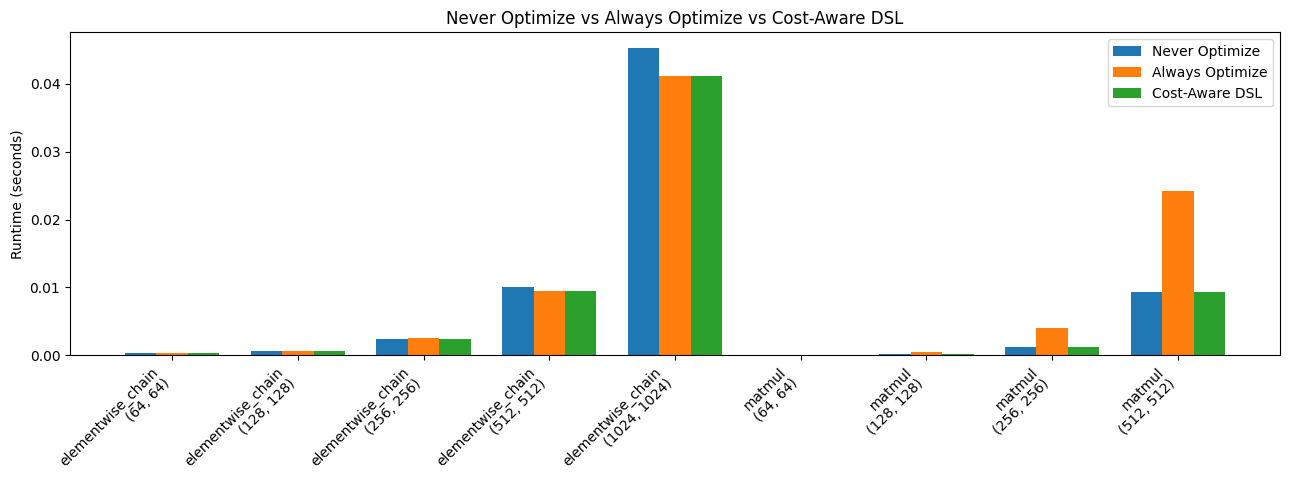

In [14]:
plot_df = comparison_df.copy()

labels = plot_df["Operation"] + "\n" + plot_df["Input Shape"].astype(str)
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(13, 5))

plt.bar(
    x - width,
    plot_df["Never Optimize Time (Baseline)"],
    width,
    label="Never Optimize"
)

plt.bar(
    x,
    plot_df["Always Optimize Time"],
    width,
    label="Always Optimize"
)

plt.bar(
    x + width,
    plot_df["DSL Selected Time"],
    width,
    label="Cost-Aware DSL"
)

plt.ylabel("Runtime (seconds)")
plt.title("Never Optimize vs Always Optimize vs Cost-Aware DSL")
plt.xticks(x, labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("strategy_comparison.png", dpi=200)
plt.show()

## Comparison Table: Never Optimize vs Always Optimize vs Cost-Aware DSL

In [15]:
comparison_modes = []

for item in dsl.history:

    timings = item["timings"]

    baseline_time = timings["baseline"]

    # Get input shape safely
    shape = item.get("input_shape", item.get("shape", "unknown"))

    # Always optimize:
    optimized_only = {
        k: v for k, v in timings.items()
        if k != "baseline"
    }

    always_optimize_strategy = min(optimized_only, key=optimized_only.get)
    always_optimize_time = optimized_only[always_optimize_strategy]

    # Never optimize:
    never_optimize_time = baseline_time

    # Adaptive DSL:
    adaptive_strategy = item["selected_strategy"]
    adaptive_time = timings[adaptive_strategy]

    comparison_modes.append({
        "Operation": item["operation"],
        "Input Shape": str(shape),
        "Never Optimize": never_optimize_time,
        "Always Optimize": always_optimize_time,
        "Adaptive DSL": adaptive_time,
        "Adaptive Strategy": adaptive_strategy
    })

modes_df = pd.DataFrame(comparison_modes)

modes_df

,Operation,Input Shape,Never Optimize,Always Optimize,Adaptive DSL,Adaptive Strategy
0,elementwise_chain,"(64, 64)",0.000253,0.000252,0.000252,fused
1,elementwise_chain,"(128, 128)",0.000598,0.000568,0.000568,fused
2,elementwise_chain,"(256, 256)",0.002419,0.002454,0.002419,baseline
3,elementwise_chain,"(512, 512)",0.010033,0.009490,0.009490,fused
4,elementwise_chain,"(1024, 1024)",0.045351,0.041180,0.041180,fused
5,matmul,"(64, 64)",0.000026,0.000032,0.000026,baseline
6,matmul,"(128, 128)",0.000160,0.000453,0.000160,baseline
7,matmul,"(256, 256)",0.001157,0.003971,0.001157,baseline
8,matmul,"(512, 512)",0.009360,0.024148,0.009360,baseline


## Final Summary of Results

In [16]:
summary_results = {
    "Never Optimize Average Runtime":
        modes_df["Never Optimize"].mean(),

    "Always Optimize Average Runtime":
        modes_df["Always Optimize"].mean(),

    "Adaptive DSL Average Runtime":
        modes_df["Adaptive DSL"].mean()
}

average_runtime_df = pd.DataFrame(
    list(summary_results.items()),
    columns=["Approach", "Average Runtime"]
)

average_runtime_df

,Approach,Average Runtime
0,Never Optimize Average Runtime,0.007706
1,Always Optimize Average Runtime,0.009172
2,Adaptive DSL Average Runtime,0.007179


## Experimental Observations

- Optimization was not always beneficial across all workloads.
- For some small tensor operations, baseline execution outperformed optimized strategies because optimization overhead was larger than the performance gain.
- For medium-sized workloads, fused execution improved elementwise chain performance.
- For some matrix multiplication workloads, tiled execution improved runtime performance.
- The adaptive DSL achieved the best overall average runtime by selecting optimization strategies only when beneficial.
- These results support the idea that optimization decisions should depend on workload characteristics rather than applying optimizations universally.

## Exporting Final Results

In [17]:
summary_df.to_csv("final_results_summary.csv", index=False)
average_runtime_df.to_csv("average_runtime_summary.csv", index=False)
detailed_df.to_csv("final_results_detailed.csv", index=False)
benefit_df.to_csv("optimization_benefit_analysis.csv", index=False)
comparison_df.to_csv("strategy_comparison.csv", index=False)
modes_df.to_csv("adaptive_vs_baselines.csv", index=False)

print("Saved files:")
print("final_results_summary.csv")
print("average_runtime_summary.csv")
print("final_results_detailed.csv")
print("optimization_benefit_analysis.csv")
print("strategy_comparison.csv")
print("adaptive_vs_baselines.csv")
print("baseline_vs_dsl_selected.png")
print("speedup_vs_baseline.png")
print("strategy_comparison.png")

Saved files:
final_results_summary.csv
average_runtime_summary.csv
final_results_detailed.csv
optimization_benefit_analysis.csv
strategy_comparison.csv
adaptive_vs_baselines.csv
baseline_vs_dsl_selected.png
speedup_vs_baseline.png
strategy_comparison.png


## Limitations and Future Work

This project is a research prototype rather than a full compiler system.

The cost model is based on simple heuristic rules using operation type and input size. Runtime validation is used to refine strategy selection.

The current implementation supports a limited set of tensor operations and optimization strategies. Future work could extend the DSL with additional operations, more advanced cost models, GPU execution, and integration with frameworks such as PyTorch or Triton.